# 07. Time-resolved DMFC Encoding

Goal:
- Move beyond window-averaged encoding.
- Test how neural encoding changes over time.
- Compare:
  1. neural_t ~ y_det
  2. neural_t ~ y_det + paddle_residual
  3. shuffled residual control

Main question:
Does behavioral endpoint residual explain DMFC activity beyond deterministic physical prediction over time?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"

for d in [PROCESSED_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

NEURAL_NPZ_PATH = INTERIM_DIR / "mahler_neural_ctu.npz"
BEHAVIOR_PATH = PROCESSED_DIR / "final_behavior_model_predictions_mahler.csv"

print("NEURAL_NPZ exists:", NEURAL_NPZ_PATH.exists())
print("BEHAVIOR_PATH exists:", BEHAVIOR_PATH.exists())

NEURAL_NPZ exists: True
BEHAVIOR_PATH exists: True


In [2]:
neural_npz = np.load(NEURAL_NPZ_PATH)
neural_ctu = neural_npz["neural_ctu"]

beh = pd.read_csv(BEHAVIOR_PATH)

print("neural_ctu shape:", neural_ctu.shape)
print("beh shape:", beh.shape)

# neural_ctu = condition × time × unit
n_cond, n_time, n_units = neural_ctu.shape

display(beh.head())

neural_ctu shape: (79, 100, 100)
beh shape: (79, 58)


,condition_i,meta_index,occ_idx,final_idx,n_steps,x_occ,y_occ,vx_occ,vy_occ,pred_x_final,pred_y_final,true_x_final,true_y_final,paddle_y_final,error_pred_vs_true,abs_error_pred_vs_true,error_paddle_vs_true,abs_error_paddle_vs_true,error_paddle_vs_pred,abs_error_paddle_vs_pred,n_bounce,heading0,speed0,vx_trace_step,vy_trace_step,horizon_steps_occ_to_final,n_trials,success_rate,failure_rate,ignore_rate,mean_paddle_error,mean_paddle_error_signed,y_det,y_true,y_paddle,abs_y_occ,abs_vy_occ,abs_y_det,signed_paddle_error,abs_paddle_error,pred_M0_det,sigma_M0_det,pred_M1_biased_det,sigma_M1_biased_det,pred_M2_heuristic,sigma_M2_heuristic,pred_M3_mc_ipe,sigma_M3_mc_ipe,uncertainty_M3_mc_ipe,pred_M4_biased_mc_ipe,sigma_M4_biased_mc_ipe,uncertainty_M4_mc,pred_M5_hetero_det,sigma_M5_hetero_det,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6
0,0,29337.0,41,56,15,5.017654,-2.787992,0.335375,0.167776,10.048274,-0.271351,10.048275,-0.271351,-0.688933,6.364749e-08,6.364749e-08,-0.417582,0.417582,-0.417582,0.417582,1.0,0.463859,0.50,0.335375,0.167776,15,142,0.654930,0.190141,0.154930,1.016034,-0.405027,-0.271351,-0.271351,-0.688933,2.787992,0.167776,0.271351,-0.417582,0.417582,-0.271351,1.512199,-0.387616,1.343921,-0.820229,1.444340,-0.717167,1.547092,0.568326,-0.612109,1.521794,1.463708,-0.387616,0.759767,-0.230727,0.718746,-0.069906,0.948261
1,1,55062.0,41,56,15,5.160105,-8.066386,0.318018,0.198720,9.930375,-5.085588,9.930375,-5.085590,-3.723874,1.861446e-06,1.861446e-06,1.361716,1.361716,1.361714,1.361714,0.0,-0.565065,0.50,0.316708,-0.200801,15,124,0.612903,0.370968,0.016129,1.599905,0.487836,-5.085588,-5.085590,-3.723874,8.066386,0.198720,5.085588,1.361716,1.361716,-5.085588,1.567046,-4.704735,1.356974,-2.815561,1.633471,-5.308730,1.527418,0.290777,-4.955276,1.517295,1.426141,-4.704735,0.635699,-4.839890,0.630025,-5.188814,0.958497
2,2,58244.0,41,56,15,5.148340,-2.995164,0.316708,-0.200802,9.898955,-6.007187,9.890882,-6.007161,-5.745208,-2.628687e-05,2.628687e-05,0.261953,0.261953,0.261979,0.261979,1.0,-0.565065,0.50,0.316708,-0.200802,15,123,0.699187,0.260163,0.040650,1.400058,0.675314,-6.007187,-6.007161,-5.745208,2.995164,0.200802,6.007187,0.261953,0.261953,-6.007187,1.567046,-5.497139,1.356974,-4.740851,1.633471,-5.830621,1.696721,0.793983,-5.694956,1.523911,1.454085,-5.497139,0.644570,-5.584061,0.638817,-6.045057,1.039976
3,3,59920.0,36,49,13,5.222656,-4.450462,0.370473,-0.423268,10.038807,-9.952948,10.040118,-9.766393,-7.246475,-1.865550e-01,1.865550e-01,2.519918,2.519918,2.706473,2.706473,1.0,-0.851814,0.75,0.370473,-0.423268,13,117,0.410256,0.529915,0.059829,2.133472,2.086257,-9.952948,-9.766393,-7.246475,4.450462,0.423268,9.952948,2.519918,2.519918,-9.952948,1.404889,-8.925939,1.239052,-8.834230,1.607278,-9.607169,1.339460,0.156179,-8.132695,1.327884,0.824287,-8.925939,0.627907,-8.336010,0.591463,-9.230822,0.537432
4,4,68220.0,42,58,16,5.200805,1.952503,0.298667,0.226767,9.979475,5.580770,9.979475,5.580769,5.144827,7.902510e-08,7.902510e-08,-0.435943,0.435943,-0.435943,0.435943,0.0,0.649403,0.50,0.298667,0.226767,16,128,0.742188,0.210938,0.046875,1.293350,-0.610159,5.580770,5.580769,5.144827,1.952503,0.226767,5.580770,-0.435943,0.435943,5.580770,1.512199,4.717728,1.343921,3.706159,1.444340,5.451764,1.547547,0.569565,4.894367,1.589112,1.726305,4.717728,0.833022,4.717494,0.788046,5.528507,0.888707


In [3]:
cond_df = (
    beh[["condition_i", "y_det", "y_paddle"]]
    .drop_duplicates("condition_i")
    .sort_values("condition_i")
    .reset_index(drop=True)
)

valid = np.isfinite(cond_df["y_det"]) & np.isfinite(cond_df["y_paddle"])

coef = np.polyfit(
    cond_df.loc[valid, "y_det"],
    cond_df.loc[valid, "y_paddle"],
    deg=1,
)

gain_global = coef[0]
intercept_global = coef[1]

cond_df["y_paddle_pred_from_y_det"] = (
    gain_global * cond_df["y_det"] + intercept_global
)

cond_df["paddle_residual_from_y_det"] = (
    cond_df["y_paddle"] - cond_df["y_paddle_pred_from_y_det"]
)

print("global gain:", gain_global)
print("global intercept:", intercept_global)

display(cond_df.head())
display(cond_df[["y_det", "y_paddle", "paddle_residual_from_y_det"]].describe())

global gain: 0.8736645456633193
global intercept: -0.21198693774335028


,condition_i,y_det,y_paddle,y_paddle_pred_from_y_det,paddle_residual_from_y_det
0,0,-0.271351,-0.688933,-0.449056,-0.239876
1,1,-5.085588,-3.723874,-4.655085,0.931211
2,2,-6.007187,-5.745208,-5.460253,-0.284955
3,3,-9.952948,-7.246475,-8.907524,1.661049
4,4,5.580770,5.144827,4.663734,0.481093


,y_det,y_paddle,paddle_residual_from_y_det
count,79.000000,79.000000,7.900000e+01
mean,-0.477061,-0.628778,-7.869935e-17
std,5.493333,4.965906,1.275402e+00
min,-9.952948,-7.246475,-5.362132e+00
25%,-5.397652,-5.832213,-4.904320e-01
50%,-0.951839,-1.275821,-2.143867e-02
75%,4.711319,4.725959,5.322101e-01
max,9.259599,6.920324,4.797325e+00


In [4]:
assert cond_df["condition_i"].nunique() == n_cond
assert set(cond_df["condition_i"].astype(int)) == set(range(n_cond))

cond_df = cond_df.sort_values("condition_i").reset_index(drop=True)

print("condition alignment OK")

condition alignment OK


In [5]:
# helpers

def make_kfold_indices(n, n_splits=5, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, n_splits)
    
    splits = []
    for i in range(n_splits):
        test_idx = folds[i]
        train_idx = np.setdiff1d(idx, test_idx)
        splits.append((train_idx, test_idx))
    
    return splits


def standardize_train_test(X_train, X_test, eps=1e-8):
    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    
    mean = np.nanmean(X_train, axis=0)
    std = np.nanstd(X_train, axis=0)
    std = np.where(std < eps, 1.0, std)
    
    X_train_z = (X_train - mean) / std
    X_test_z = (X_test - mean) / std
    
    X_train_z = np.where(np.isfinite(X_train_z), X_train_z, 0.0)
    X_test_z = np.where(np.isfinite(X_test_z), X_test_z, 0.0)
    
    return X_train_z, X_test_z


def add_intercept(X):
    X = np.asarray(X, dtype=float)
    return np.column_stack([np.ones(len(X)), X])


def fit_ridge(X, Y, alpha=1.0):
    I = np.eye(X.shape[1])
    return np.linalg.solve(X.T @ X + alpha * I, X.T @ Y)


def score_population_r2(Y_true, Y_pred):
    mask = np.isfinite(Y_true)
    
    if mask.sum() == 0:
        return np.nan, np.nan, np.nan
    
    residual = Y_true[mask] - Y_pred[mask]
    sse = np.sum(residual ** 2)
    sst = np.sum(Y_true[mask] ** 2)
    
    r2 = 1.0 - sse / sst if sst > 0 else np.nan
    
    return r2, sse, sst

In [6]:
def evaluate_timebin_encoding(
    neural_ctu,
    cond_df,
    features,
    time_bin,
    n_splits=5,
    seed=42,
    alpha=1.0,
    min_unit_finite=0.2,
):
    """
    Evaluate encoding at one time bin.
    
    neural_ctu: condition × time × unit
    features: list of feature columns in cond_df
    """
    Y_raw = neural_ctu[:, time_bin, :]
    X_raw = cond_df[features].to_numpy(dtype=float)
    
    # Unit filtering
    finite_ratio = np.isfinite(Y_raw).mean(axis=0)
    unit_std = np.nanstd(Y_raw, axis=0)
    
    keep_units = (
        (finite_ratio >= min_unit_finite) &
        np.isfinite(unit_std) &
        (unit_std > 1e-8)
    )
    
    if keep_units.sum() < 3:
        keep_units = (
            (finite_ratio >= 0.05) &
            np.isfinite(unit_std) &
            (unit_std > 1e-8)
        )
    
    Y_raw = Y_raw[:, keep_units]
    
    # Valid rows
    valid_x = np.isfinite(X_raw).any(axis=1)
    X_raw = X_raw[valid_x]
    Y_raw = Y_raw[valid_x]
    
    splits = make_kfold_indices(len(X_raw), n_splits=n_splits, seed=seed)
    
    all_sse = 0.0
    all_sst = 0.0
    
    fold_rows = []
    
    for fold, (train_idx, test_idx) in enumerate(splits):
        X_train_raw = X_raw[train_idx]
        X_test_raw = X_raw[test_idx]
        
        Y_train_raw = Y_raw[train_idx]
        Y_test_raw = Y_raw[test_idx]
        
        # X standardization
        X_train_z, X_test_z = standardize_train_test(X_train_raw, X_test_raw)
        X_train_design = add_intercept(X_train_z)
        X_test_design = add_intercept(X_test_z)
        
        # Y standardization using train only
        y_mean = np.nanmean(Y_train_raw, axis=0, keepdims=True)
        y_std = np.nanstd(Y_train_raw, axis=0, keepdims=True)
        y_std = np.where(y_std < 1e-8, 1.0, y_std)
        
        Y_train_z = (Y_train_raw - y_mean) / y_std
        Y_test_z = (Y_test_raw - y_mean) / y_std
        
        Y_train_z_fit = np.where(np.isfinite(Y_train_z), Y_train_z, 0.0)
        
        beta = fit_ridge(X_train_design, Y_train_z_fit, alpha=alpha)
        Y_pred_z = X_test_design @ beta
        
        fold_r2, sse, sst = score_population_r2(Y_test_z, Y_pred_z)
        
        if np.isfinite(sse):
            all_sse += sse
            all_sst += sst
        
        fold_rows.append({
            "time_bin": time_bin,
            "fold": fold,
            "features": ",".join(features),
            "n_features": len(features),
            "n_units": keep_units.sum(),
            "fold_population_r2": fold_r2,
            "sse": sse,
            "sst": sst,
        })
    
    pop_r2 = 1.0 - all_sse / all_sst if all_sst > 0 else np.nan
    
    return pd.DataFrame(fold_rows), pop_r2

In [ ]:
'''
base: y_det
residual: y_det + paddle_residual
behavior: y_paddle
'''

time_models = {
    "base_y_det": ["y_det"],
    "base_plus_paddle_residual": ["y_det", "paddle_residual_from_y_det"],
    "behavior_y_paddle": ["y_paddle"],
}

time_rows = []
time_fold_rows = []

for t in range(n_time):
    for model_name, feats in time_models.items():
        cv_df, pop_r2 = evaluate_timebin_encoding(
            neural_ctu=neural_ctu,
            cond_df=cond_df,
            features=feats,
            time_bin=t,
            n_splits=5,
            seed=42,
            alpha=1.0,
            min_unit_finite=0.2,
        )
        
        time_rows.append({
            "time_bin": t,
            "model": model_name,
            "features": ",".join(feats),
            "population_r2": pop_r2,
            "mean_fold_r2": cv_df["fold_population_r2"].mean(),
            "sem_fold_r2": cv_df["fold_population_r2"].std(ddof=1) / np.sqrt(len(cv_df)),
            "n_features": len(feats),
            "n_units": cv_df["n_units"].iloc[0],
        })
        
        cv_df["model"] = model_name
        time_fold_rows.append(cv_df)

time_encoding = pd.DataFrame(time_rows)
time_folds = pd.concat(time_fold_rows, ignore_index=True)

display(time_encoding.head()) # type: ignore

c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,time_bin,model,features,population_r2,mean_fold_r2,sem_fold_r2,n_features,n_units
0,0,base_y_det,y_det,0.277294,0.264234,0.060659,1,28
1,0,base_plus_paddle_residual,"y_det,paddle_residual_from_y_det",0.279295,0.267134,0.059276,2,28
2,0,behavior_y_paddle,y_paddle,0.270601,0.252809,0.056161,1,28
3,1,base_y_det,y_det,0.291756,0.280142,0.040708,1,28
4,1,base_plus_paddle_residual,"y_det,paddle_residual_from_y_det",0.315081,0.309754,0.037694,2,28


In [8]:
time_wide = time_encoding.pivot(
    index="time_bin",
    columns="model",
    values="population_r2",
).reset_index()

time_wide["delta_residual_over_y_det"] = (
    time_wide["base_plus_paddle_residual"] - time_wide["base_y_det"]
)

time_wide["delta_behavior_over_y_det"] = (
    time_wide["behavior_y_paddle"] - time_wide["base_y_det"]
)

display(time_wide.head())
display(time_wide.describe())

model,time_bin,base_plus_paddle_residual,base_y_det,behavior_y_paddle,delta_residual_over_y_det,delta_behavior_over_y_det
0,0,0.279295,0.277294,0.270601,0.002001,-0.006693
1,1,0.315081,0.291756,0.332735,0.023325,0.040978
2,2,0.392100,0.397589,0.387826,-0.005489,-0.009763
3,3,0.298475,0.298694,0.294653,-0.000219,-0.004041
4,4,0.249514,0.198779,0.252279,0.050735,0.053501


model,time_bin,base_plus_paddle_residual,base_y_det,behavior_y_paddle,delta_residual_over_y_det,delta_behavior_over_y_det
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49.500000,0.306625,0.290544,0.312909,0.016081,0.022366
std,29.011492,0.035626,0.038700,0.033849,0.019242,0.017939
min,0.000000,0.199045,0.198779,0.232480,-0.030661,-0.014189
25%,24.750000,0.281198,0.264253,0.288591,0.002319,0.010796
50%,49.500000,0.304409,0.285380,0.310206,0.012882,0.021858
75%,74.250000,0.328082,0.313482,0.335295,0.027110,0.034194
max,99.000000,0.420595,0.415084,0.416783,0.071615,0.065841


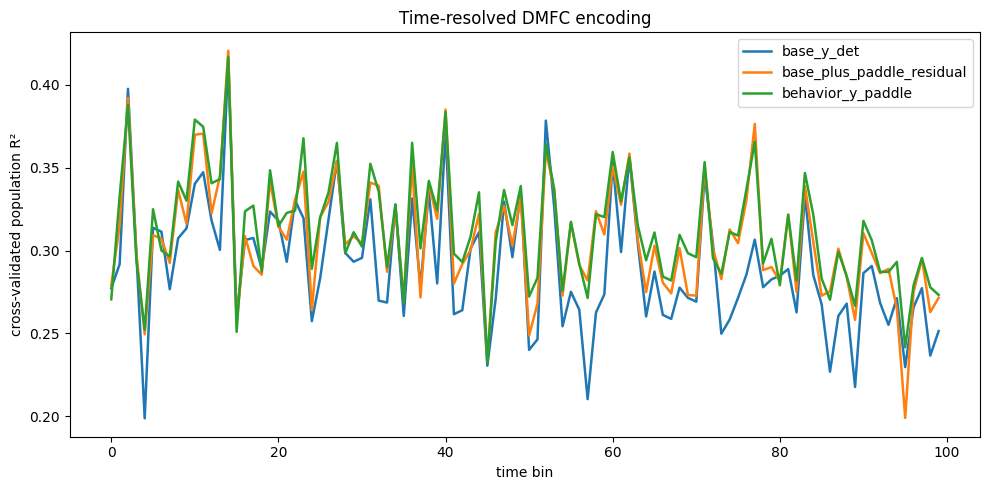

In [9]:
plt.figure(figsize=(10, 5))

for model_name in ["base_y_det", "base_plus_paddle_residual", "behavior_y_paddle"]:
    plt.plot(
        time_wide["time_bin"],
        time_wide[model_name],
        label=model_name,
        linewidth=1.8,
    )

plt.xlabel("time bin")
plt.ylabel("cross-validated population R²")
plt.title("Time-resolved DMFC encoding")
plt.legend()
plt.tight_layout()
plt.show()

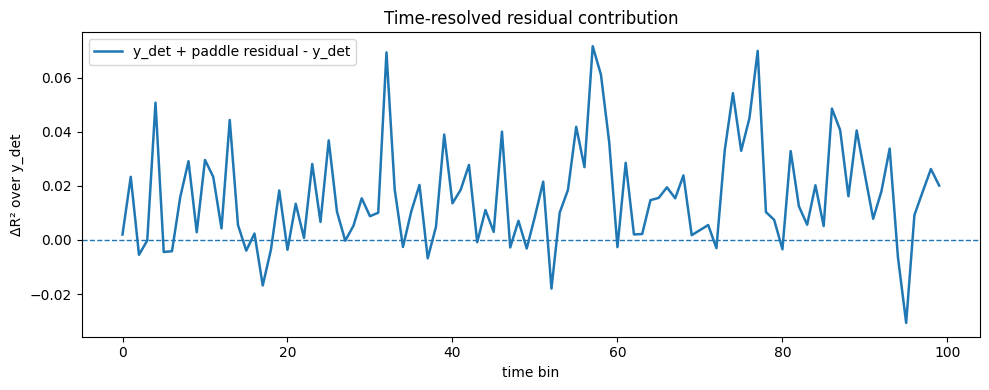

In [10]:
plt.figure(figsize=(10, 4))

plt.plot(
    time_wide["time_bin"],
    time_wide["delta_residual_over_y_det"],
    label="y_det + paddle residual - y_det",
    linewidth=1.8,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("time bin")
plt.ylabel("ΔR² over y_det")
plt.title("Time-resolved residual contribution")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
def run_time_resolved_residual_shuffle(
    neural_ctu,
    cond_df,
    n_shuffle=100,
    seed=123,
):
    rng = np.random.default_rng(seed)
    
    observed = time_wide[[
        "time_bin",
        "base_y_det",
        "base_plus_paddle_residual",
        "delta_residual_over_y_det",
    ]].copy()
    
    shuffle_rows = []
    
    base_values = cond_df[["condition_i", "y_det", "paddle_residual_from_y_det"]].copy()
    
    for s in range(n_shuffle):
        shuf_cond = base_values.copy()
        
        shuffled_resid = shuf_cond["paddle_residual_from_y_det"].values.copy()
        rng.shuffle(shuffled_resid)
        
        shuf_cond["paddle_residual_shuffled"] = shuffled_resid
        
        for t in range(n_time):
            _, r2_base = evaluate_timebin_encoding(
                neural_ctu=neural_ctu,
                cond_df=shuf_cond,
                features=["y_det"],
                time_bin=t,
                n_splits=5,
                seed=42,
                alpha=1.0,
                min_unit_finite=0.2,
            )
            
            _, r2_shuf = evaluate_timebin_encoding(
                neural_ctu=neural_ctu,
                cond_df=shuf_cond,
                features=["y_det", "paddle_residual_shuffled"],
                time_bin=t,
                n_splits=5,
                seed=42,
                alpha=1.0,
                min_unit_finite=0.2,
            )
            
            shuffle_rows.append({
                "shuffle": s,
                "time_bin": t,
                "base_r2": r2_base,
                "shuffled_r2": r2_shuf,
                "shuffled_delta_r2": r2_shuf - r2_base,
            })
    
    shuffle_df = pd.DataFrame(shuffle_rows)
    
    summary_rows = []
    
    for t in range(n_time):
        obs_delta = observed.loc[
            observed["time_bin"] == t,
            "delta_residual_over_y_det",
        ].iloc[0]
        
        shuf = shuffle_df.loc[
            shuffle_df["time_bin"] == t,
            "shuffled_delta_r2",
        ].values
        
        p_empirical = (np.sum(shuf >= obs_delta) + 1) / (len(shuf) + 1)
        
        summary_rows.append({
            "time_bin": t,
            "observed_delta_r2": obs_delta,
            "shuffle_mean_delta": np.mean(shuf),
            "shuffle_std_delta": np.std(shuf, ddof=1),
            "shuffle_p95": np.percentile(shuf, 95),
            "shuffle_p99": np.percentile(shuf, 99),
            "empirical_p": p_empirical,
        })
    
    summary_df = pd.DataFrame(summary_rows)
    
    return summary_df, shuffle_df


time_shuffle_summary, time_shuffle_dist = run_time_resolved_residual_shuffle(
    neural_ctu=neural_ctu,
    cond_df=cond_df,
    n_shuffle=100,
    seed=123,
)

display(time_shuffle_summary.head())

c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,time_bin,observed_delta_r2,shuffle_mean_delta,shuffle_std_delta,shuffle_p95,shuffle_p99,empirical_p
0,0,0.002001,-0.006547,0.012035,0.007390,0.024644,0.158416
1,1,0.023325,-0.005077,0.010909,0.007554,0.026985,0.029703
2,2,-0.005489,-0.006344,0.008105,0.004088,0.017287,0.475248
3,3,-0.000219,-0.005054,0.010449,0.012904,0.027441,0.287129
4,4,0.050735,-0.005080,0.011262,0.015282,0.021975,0.009901


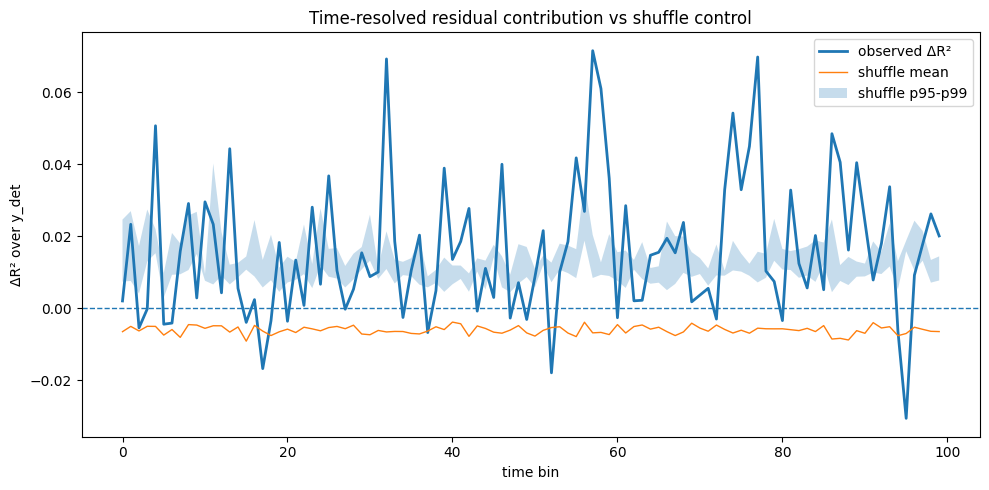

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_shuffle_summary["time_bin"],
    time_shuffle_summary["observed_delta_r2"],
    label="observed ΔR²",
    linewidth=2,
)

plt.plot(
    time_shuffle_summary["time_bin"],
    time_shuffle_summary["shuffle_mean_delta"],
    label="shuffle mean",
    linewidth=1,
)

plt.fill_between(
    time_shuffle_summary["time_bin"],
    time_shuffle_summary["shuffle_p95"],
    time_shuffle_summary["shuffle_p99"],
    alpha=0.25,
    label="shuffle p95-p99",
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("time bin")
plt.ylabel("ΔR² over y_det")
plt.title("Time-resolved residual contribution vs shuffle control")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
sig_bins = time_shuffle_summary[
    time_shuffle_summary["empirical_p"] < 0.05
].copy()

print("Number of significant bins:", len(sig_bins))
display(sig_bins.head(30))

# contiguous significant segments
sig = time_shuffle_summary["empirical_p"].values < 0.05

segments = []
start = None

for i, is_sig in enumerate(sig):
    if is_sig and start is None:
        start = i
    elif not is_sig and start is not None:
        segments.append((start, i - 1))
        start = None

if start is not None:
    segments.append((start, len(sig) - 1))

segments

Number of significant bins: 56


,time_bin,observed_delta_r2,shuffle_mean_delta,shuffle_std_delta,shuffle_p95,shuffle_p99,empirical_p
1,1,0.023325,-0.005077,0.010909,0.007554,0.026985,0.029703
4,4,0.050735,-0.005080,0.011262,0.015282,0.021975,0.009901
7,7,0.015837,-0.008134,0.011466,0.009415,0.017986,0.029703
8,8,0.029111,-0.004582,0.011633,0.010593,0.025746,0.019802
10,10,0.029568,-0.005620,0.008226,0.007610,0.009500,0.009901
11,11,0.023320,-0.004903,0.011136,0.006592,0.040249,0.029703
13,13,0.044345,-0.006664,0.009738,0.006595,0.012095,0.009901
19,19,0.018271,-0.006583,0.008397,0.004530,0.011246,0.009901
21,21,0.013362,-0.006789,0.011721,0.007884,0.012880,0.019802
23,23,0.028086,-0.005766,0.008304,0.005564,0.012289,0.009901


[(1, 1),
 (4, 4),
 (7, 8),
 (10, 11),
 (13, 13),
 (19, 19),
 (21, 21),
 (23, 23),
 (25, 25),
 (29, 29),
 (31, 33),
 (35, 36),
 (39, 42),
 (44, 44),
 (46, 46),
 (50, 51),
 (54, 59),
 (61, 61),
 (64, 68),
 (73, 78),
 (81, 82),
 (84, 84),
 (86, 90),
 (92, 93),
 (97, 99)]

mean occ_idx: 30.82278481012658
mean final_idx: 49.32911392405063


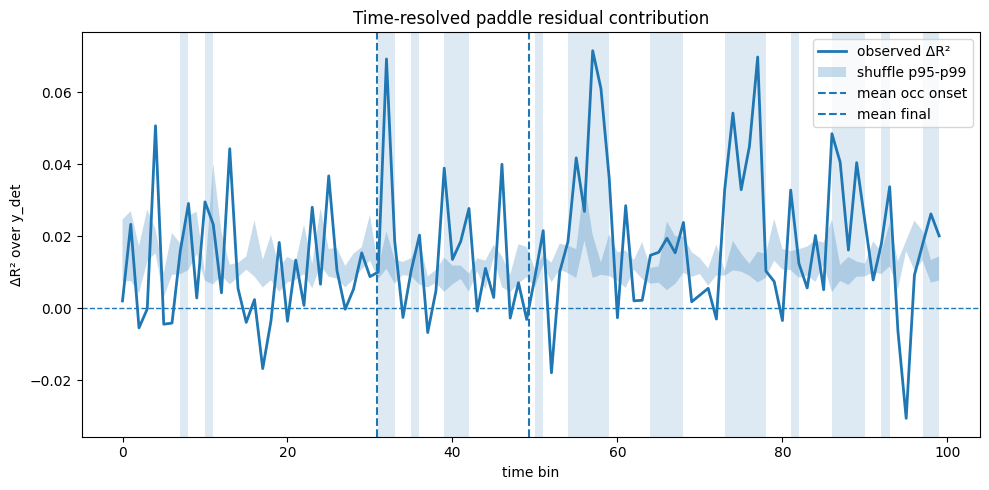

In [14]:
mean_occ_idx = beh["occ_idx"].mean()
mean_final_idx = beh["final_idx"].mean()

print("mean occ_idx:", mean_occ_idx)
print("mean final_idx:", mean_final_idx)

plt.figure(figsize=(10, 5))

plt.plot(
    time_shuffle_summary["time_bin"],
    time_shuffle_summary["observed_delta_r2"],
    label="observed ΔR²",
    linewidth=2,
)

plt.fill_between(
    time_shuffle_summary["time_bin"],
    time_shuffle_summary["shuffle_p95"],
    time_shuffle_summary["shuffle_p99"],
    alpha=0.25,
    label="shuffle p95-p99",
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(mean_occ_idx, linestyle="--", linewidth=1.5, label="mean occ onset")
plt.axvline(mean_final_idx, linestyle="--", linewidth=1.5, label="mean final")

for start, end in segments:
    plt.axvspan(start, end, alpha=0.15)

plt.xlabel("time bin")
plt.ylabel("ΔR² over y_det")
plt.title("Time-resolved paddle residual contribution")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
TIME_ENCODING_PATH = PROCESSED_DIR / "dmfc_time_resolved_encoding_mahler.csv"
TIME_FOLDS_PATH = PROCESSED_DIR / "dmfc_time_resolved_encoding_folds_mahler.csv"
TIME_WIDE_PATH = PROCESSED_DIR / "dmfc_time_resolved_delta_r2_mahler.csv"
TIME_SHUFFLE_SUMMARY_PATH = PROCESSED_DIR / "dmfc_time_resolved_residual_shuffle_summary_mahler.csv"
TIME_SHUFFLE_DIST_PATH = PROCESSED_DIR / "dmfc_time_resolved_residual_shuffle_dist_mahler.csv"

time_encoding.to_csv(TIME_ENCODING_PATH, index=False)
time_folds.to_csv(TIME_FOLDS_PATH, index=False)
time_wide.to_csv(TIME_WIDE_PATH, index=False)
time_shuffle_summary.to_csv(TIME_SHUFFLE_SUMMARY_PATH, index=False)
time_shuffle_dist.to_csv(TIME_SHUFFLE_DIST_PATH, index=False)

print("Saved:", TIME_ENCODING_PATH)
print("Saved:", TIME_FOLDS_PATH)
print("Saved:", TIME_WIDE_PATH)
print("Saved:", TIME_SHUFFLE_SUMMARY_PATH)
print("Saved:", TIME_SHUFFLE_DIST_PATH)

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_time_resolved_encoding_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_time_resolved_encoding_folds_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_time_resolved_delta_r2_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_time_resolved_residual_shuffle_summary_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_time_resolved_residual_shuffle_dist_mahler.csv


In [16]:
def find_clusters_above_threshold(values, threshold):
    """
    Find contiguous clusters where values > threshold.
    Returns list of (start, end, mass).
    mass = sum(values - threshold) within cluster.
    """
    values = np.asarray(values)
    above = values > threshold
    
    clusters = []
    start = None
    
    for i, is_above in enumerate(above):
        if is_above and start is None:
            start = i
        elif (not is_above) and start is not None:
            end = i - 1
            mass = np.sum(values[start:end+1] - threshold)
            clusters.append((start, end, mass))
            start = None
    
    if start is not None:
        end = len(values) - 1
        mass = np.sum(values[start:end+1] - threshold)
        clusters.append((start, end, mass))
    
    return clusters


# Use a global null threshold from shuffled deltas.
# This is simpler and conservative enough for preliminary analysis.
global_threshold = np.percentile(
    time_shuffle_dist["shuffled_delta_r2"].values,
    95
)

print("Global 95% shuffle threshold:", global_threshold)

observed_values = time_shuffle_summary.sort_values("time_bin")["observed_delta_r2"].values
observed_clusters = find_clusters_above_threshold(
    observed_values,
    threshold=global_threshold,
)

observed_clusters_df = pd.DataFrame(
    observed_clusters,
    columns=["cluster_start", "cluster_end", "cluster_mass"]
)

observed_clusters_df["cluster_len"] = (
    observed_clusters_df["cluster_end"] - observed_clusters_df["cluster_start"] + 1
)

display(observed_clusters_df.sort_values("cluster_mass", ascending=False))

Global 95% shuffle threshold: 0.009158195405985158


,cluster_start,cluster_end,cluster_mass,cluster_len
16,53,59,0.202004,7
19,73,78,0.190411,6
22,86,90,0.123999,5
10,31,33,0.070502,3
12,39,42,0.062140,4
18,64,68,0.043113,5
1,4,4,0.041577,1
24,96,99,0.036640,4
4,13,13,0.035186,1
3,10,11,0.034571,2


In [17]:
max_cluster_rows = []

for s, sub in time_shuffle_dist.groupby("shuffle"):
    sub = sub.sort_values("time_bin")
    values = sub["shuffled_delta_r2"].values
    
    clusters = find_clusters_above_threshold(
        values,
        threshold=global_threshold,
    )
    
    if len(clusters) == 0:
        max_mass = 0.0
        max_len = 0
    else:
        max_mass = max(c[2] for c in clusters)
        max_len = max(c[1] - c[0] + 1 for c in clusters)
    
    max_cluster_rows.append({
        "shuffle": s,
        "max_cluster_mass": max_mass,
        "max_cluster_len": max_len,
    })

max_cluster_df = pd.DataFrame(max_cluster_rows)

display(max_cluster_df.describe())

,shuffle,max_cluster_mass,max_cluster_len
count,100.000000,100.000000,100.000000
mean,49.500000,0.012258,1.240000
std,29.011492,0.010725,0.605029
min,0.000000,0.000000,0.000000
25%,24.750000,0.004843,1.000000
50%,49.500000,0.008813,1.000000
75%,74.250000,0.016445,1.000000
max,99.000000,0.050963,4.000000


In [18]:
cluster_p_rows = []

for _, row in observed_clusters_df.iterrows():
    obs_mass = row["cluster_mass"]
    
    p = (
        np.sum(max_cluster_df["max_cluster_mass"].values >= obs_mass) + 1
    ) / (len(max_cluster_df) + 1)
    
    cluster_p_rows.append({
        "cluster_start": int(row["cluster_start"]),
        "cluster_end": int(row["cluster_end"]),
        "cluster_len": int(row["cluster_len"]),
        "cluster_mass": row["cluster_mass"],
        "cluster_p": p,
    })

cluster_p_df = pd.DataFrame(cluster_p_rows).sort_values("cluster_mass", ascending=False)

display(cluster_p_df)

,cluster_start,cluster_end,cluster_len,cluster_mass,cluster_p
16,53,59,7,0.202004,0.009901
19,73,78,6,0.190411,0.009901
22,86,90,5,0.123999,0.009901
10,31,33,3,0.070502,0.009901
12,39,42,4,0.062140,0.009901
18,64,68,5,0.043113,0.019802
1,4,4,1,0.041577,0.019802
24,96,99,4,0.036640,0.059406
4,13,13,1,0.035186,0.069307
3,10,11,2,0.034571,0.069307


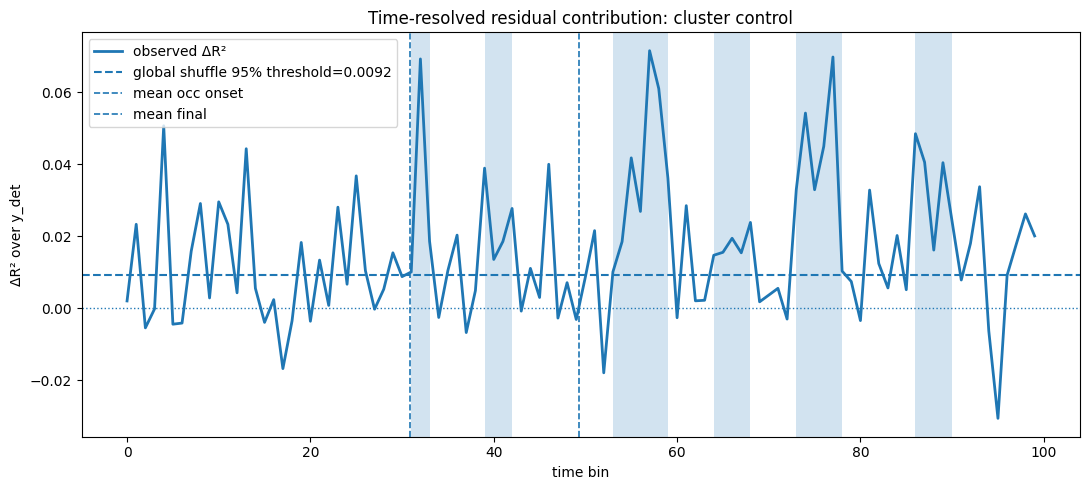

In [19]:
plt.figure(figsize=(11, 5))

plt.plot(
    time_shuffle_summary["time_bin"],
    time_shuffle_summary["observed_delta_r2"],
    label="observed ΔR²",
    linewidth=2,
)

plt.axhline(
    global_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"global shuffle 95% threshold={global_threshold:.4f}",
)

plt.axhline(0, linestyle=":", linewidth=1)

# event lines
mean_occ_idx = beh["occ_idx"].mean()
mean_final_idx = beh["final_idx"].mean()

plt.axvline(mean_occ_idx, linestyle="--", linewidth=1.2, label="mean occ onset")
plt.axvline(mean_final_idx, linestyle="--", linewidth=1.2, label="mean final")

# significant clusters
for _, row in cluster_p_df.iterrows():
    if row["cluster_p"] < 0.05:
        plt.axvspan(
            row["cluster_start"],
            row["cluster_end"],
            alpha=0.2,
        )

plt.xlabel("time bin")
plt.ylabel("ΔR² over y_det")
plt.title("Time-resolved residual contribution: cluster control")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
CLUSTER_PATH = PROCESSED_DIR / "dmfc_time_resolved_residual_cluster_summary_mahler.csv"
MAX_CLUSTER_PATH = PROCESSED_DIR / "dmfc_time_resolved_residual_shuffle_max_cluster_mahler.csv"

cluster_p_df.to_csv(CLUSTER_PATH, index=False)
max_cluster_df.to_csv(MAX_CLUSTER_PATH, index=False)

print("Saved:", CLUSTER_PATH)
print("Saved:", MAX_CLUSTER_PATH)

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_time_resolved_residual_cluster_summary_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_time_resolved_residual_shuffle_max_cluster_mahler.csv


DMFC population activity는 deterministic physical target인 y_det만으로 설명되는 성분 외에도, behavioral endpoint residual과 정렬되는 추가적인 condition-wise variance를 가진다. 이 효과는 window-average 분석뿐 아니라 time-resolved cluster control에서도 확인되며, 특히 occlusion onset 직후와 occlusion period 내부에서도 나타난다.